# Correlation Inflation in CCA

This notebook studies a high-dimensional failure mode of Canonical Correlation Analysis (CCA): sample CCA can report strong canonical correlations even when two datasets are independent.

It contains seven experiments:

1. Repeated null simulations with uncertainty bands  
2. Separate sweeps over \(p/n\) and \(q/n\)  
3. Ridge-regularization sweep  
4. Controlled shared-signal experiment  
5. Train-versus-test inflation under the null model  
6. Comparison of stabilization strategies  
7. Regularizing the objective of a learned linear contrastive encoder  

Use `QUICK_MODE = True` for a fast first run. Switch it to `False` for smoother curves and more Monte Carlo repetitions.

## 0. Imports and configuration

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.covariance import LedoitWolf
except ImportError as exc:
    raise ImportError("Install scikit-learn with: pip install scikit-learn") from exc

GLOBAL_SEED = 123
QUICK_MODE = True

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("QUICK_MODE =", QUICK_MODE)

QUICK_MODE = True


## 1. Shared utilities

Ordinary CCA whitens the two datasets and then applies SVD to the whitened cross-covariance matrix.

Ridge CCA modifies the whitening step by adding a positive diagonal term to each within-view covariance matrix before inversion.

In [2]:
def inverse_sqrt_psd(
    matrix: np.ndarray,
    ridge: float = 0.0,
    eigenvalue_floor: float = 1e-10,
) -> np.ndarray:
    """Return (matrix + ridge * I)^(-1/2) for a symmetric PSD matrix."""
    if ridge < 0:
        raise ValueError("ridge must be non-negative")

    matrix = np.asarray(matrix, dtype=float)
    matrix = 0.5 * (matrix + matrix.T)

    values, vectors = np.linalg.eigh(matrix)
    values = np.maximum(values + ridge, eigenvalue_floor)

    return (vectors / np.sqrt(values)) @ vectors.T


@dataclass
class CCAFit:
    correlations: np.ndarray
    directions_x: np.ndarray
    directions_y: np.ndarray
    mean_x: np.ndarray
    mean_y: np.ndarray


def fit_cca(
    X: np.ndarray,
    Y: np.ndarray,
    n_components: int = 1,
    ridge_x: float = 0.0,
    ridge_y: Optional[float] = None,
    eigenvalue_floor: float = 1e-10,
) -> CCAFit:
    """Fit ordinary or ridge CCA using whitening and SVD."""
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if X.shape[0] != Y.shape[0]:
        raise ValueError("X and Y must have the same number of observations")

    if ridge_y is None:
        ridge_y = ridge_x

    mean_x = X.mean(axis=0, keepdims=True)
    mean_y = Y.mean(axis=0, keepdims=True)

    Xc = X - mean_x
    Yc = Y - mean_y

    divisor = max(X.shape[0] - 1, 1)
    S_xx = (Xc.T @ Xc) / divisor
    S_yy = (Yc.T @ Yc) / divisor
    S_xy = (Xc.T @ Yc) / divisor

    W_x = inverse_sqrt_psd(S_xx, ridge=ridge_x, eigenvalue_floor=eigenvalue_floor)
    W_y = inverse_sqrt_psd(S_yy, ridge=ridge_y, eigenvalue_floor=eigenvalue_floor)

    T = W_x @ S_xy @ W_y
    U, singular_values, Vt = np.linalg.svd(T, full_matrices=False)

    k = min(int(n_components), len(singular_values))

    return CCAFit(
        correlations=singular_values[:k],
        directions_x=W_x @ U[:, :k],
        directions_y=W_y @ Vt.T[:, :k],
        mean_x=mean_x,
        mean_y=mean_y,
    )


def project_cca(fit: CCAFit, X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    X_scores = (np.asarray(X) - fit.mean_x) @ fit.directions_x
    Y_scores = (np.asarray(Y) - fit.mean_y) @ fit.directions_y
    return X_scores, Y_scores


def columnwise_correlations(X_scores: np.ndarray, Y_scores: np.ndarray) -> np.ndarray:
    """Return correlations between corresponding columns."""
    k = min(X_scores.shape[1], Y_scores.shape[1])
    values = np.full(k, np.nan)

    for j in range(k):
        x = X_scores[:, j]
        y = Y_scores[:, j]
        if x.std(ddof=1) > 1e-12 and y.std(ddof=1) > 1e-12:
            values[j] = np.corrcoef(x, y)[0, 1]

    return values


def leading_train_test_corr(
    fit: CCAFit,
    X_train: np.ndarray,
    Y_train: np.ndarray,
    X_test: np.ndarray,
    Y_test: np.ndarray,
) -> Tuple[float, float]:
    Xtr, Ytr = project_cca(fit, X_train, Y_train)
    Xte, Yte = project_cca(fit, X_test, Y_test)

    train_corr = columnwise_correlations(Xtr[:, :1], Ytr[:, :1])[0]
    test_corr = columnwise_correlations(Xte[:, :1], Yte[:, :1])[0]

    return float(train_corr), float(test_corr)


def wachter_upper_edge(gamma_p, gamma_q):
    """Asymptotic upper edge for null sample canonical correlations."""
    gp = np.asarray(gamma_p, dtype=float)
    gq = np.asarray(gamma_q, dtype=float)

    a = np.sqrt(np.maximum(gp * (1.0 - gq), 0.0))
    b = np.sqrt(np.maximum(gq * (1.0 - gp), 0.0))

    return np.where(gp + gq >= 1.0, 1.0, a + b)

## 2. Synthetic-data generators

The null generator creates independent Gaussian datasets. Their true cross-covariance is zero.

The shared-signal generator creates two datasets containing the same latent variable plus independent noise.

In [3]:
def generate_null_data(
    n: int,
    p: int,
    q: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    X = rng.standard_normal((n, p))
    Y = rng.standard_normal((n, q))
    return X, Y


@dataclass
class SharedSignalData:
    X: np.ndarray
    Y: np.ndarray
    Z: np.ndarray
    loadings_x: np.ndarray
    loadings_y: np.ndarray


def generate_shared_signal_data(
    n: int,
    p: int,
    q: int,
    latent_dim: int,
    signal_strength: float,
    noise_std: float,
    rng: np.random.Generator,
) -> SharedSignalData:
    if latent_dim > min(p, q):
        raise ValueError("latent_dim must not exceed min(p, q)")

    Z = rng.standard_normal((n, latent_dim))

    loadings_x = rng.standard_normal((p, latent_dim))
    loadings_y = rng.standard_normal((q, latent_dim))

    loadings_x /= np.linalg.norm(loadings_x, axis=0, keepdims=True)
    loadings_y /= np.linalg.norm(loadings_y, axis=0, keepdims=True)

    X = signal_strength * (Z @ loadings_x.T) + noise_std * rng.standard_normal((n, p))
    Y = signal_strength * (Z @ loadings_y.T) + noise_std * rng.standard_normal((n, q))

    return SharedSignalData(
        X=X,
        Y=Y,
        Z=Z,
        loadings_x=loadings_x,
        loadings_y=loadings_y,
    )

# Experiment 1 — Repeated null simulations with uncertainty bands

## Purpose

Measure how the largest sample canonical correlation changes as the number of features grows relative to the number of samples.

Because the two datasets are independent, the true population correlation is zero. Any positive correlation is spurious.

,gamma,mean,q10,q90,wachter_edge
0,0.05,0.383041,0.342284,0.417181,0.435890
1,0.10,0.576257,0.542610,0.604135,0.600000
2,0.15,0.694512,0.670790,0.711719,0.714143
3,0.20,0.785489,0.774025,0.795275,0.800000
4,0.25,0.854858,0.843686,0.867588,0.866025


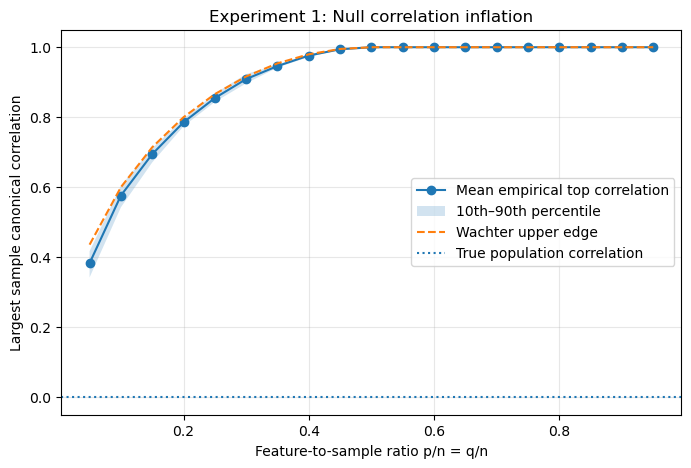

In [4]:
n = 220 if QUICK_MODE else 500
ratios = np.arange(0.05, 0.96, 0.05)
n_rep = 15 if QUICK_MODE else 100

rng = np.random.default_rng(GLOBAL_SEED)
records = []

for gamma in ratios:
    p = max(1, int(np.floor(n * gamma)))

    for rep in range(n_rep):
        X, Y = generate_null_data(n=n, p=p, q=p, rng=rng)
        fit = fit_cca(X, Y, n_components=1)

        records.append(
            {
                "gamma": gamma,
                "rep": rep,
                "top_corr": float(fit.correlations[0]),
            }
        )

exp1 = pd.DataFrame(records)

summary1 = (
    exp1.groupby("gamma")["top_corr"]
    .agg(
        mean="mean",
        q10=lambda s: s.quantile(0.10),
        q90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)

summary1["wachter_edge"] = wachter_upper_edge(summary1["gamma"], summary1["gamma"])

display(summary1.head())

fig, ax = plt.subplots()
ax.plot(summary1["gamma"], summary1["mean"], marker="o", label="Mean empirical top correlation")
ax.fill_between(summary1["gamma"], summary1["q10"], summary1["q90"], alpha=0.2, label="10th–90th percentile")
ax.plot(summary1["gamma"], summary1["wachter_edge"], linestyle="--", label="Wachter upper edge")
ax.axhline(0.0, linestyle=":", label="True population correlation")
ax.set(
    title="Experiment 1: Null correlation inflation",
    xlabel="Feature-to-sample ratio p/n = q/n",
    ylabel="Largest sample canonical correlation",
    ylim=(-0.05, 1.05),
)
ax.legend()
plt.show()

## Results

- Main pattern:
- Approximate point where inflation becomes severe:
- Agreement with the theoretical upper edge:
- Questions raised:

# Experiment 2 — Separate sweeps over \(p/n\) and \(q/n\)

## Purpose

Determine how the dimensions of both views jointly affect inflation.

This matters because two modalities often have different dimensions.

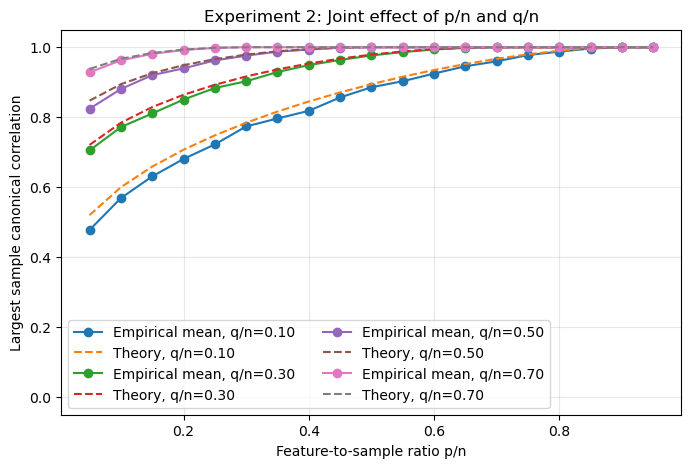

In [16]:
n = 220 if QUICK_MODE else 500
gamma_p_values = np.arange(0.05, 0.96, 0.05)
gamma_q_values = [0.10, 0.30, 0.50, 0.70]
n_rep = 8 if QUICK_MODE else 50

rng = np.random.default_rng(GLOBAL_SEED + 1)
records = []

for gamma_q in gamma_q_values:
    q = max(1, int(np.floor(n * gamma_q)))

    for gamma_p in gamma_p_values:
        p = max(1, int(np.floor(n * gamma_p)))

        for rep in range(n_rep):
            X, Y = generate_null_data(n=n, p=p, q=q, rng=rng)
            fit = fit_cca(X, Y, n_components=1)

            records.append(
                {
                    "gamma_p": gamma_p,
                    "gamma_q": gamma_q,
                    "rep": rep,
                    "top_corr": float(fit.correlations[0]),
                }
            )

exp2 = pd.DataFrame(records)

summary2 = (
    exp2.groupby(["gamma_p", "gamma_q"])["top_corr"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots()

for gamma_q in gamma_q_values:
    subset = summary2[summary2["gamma_q"] == gamma_q].sort_values("gamma_p")

    ax.plot(
        subset["gamma_p"],
        subset["top_corr"],
        marker="o",
        label=f"Empirical mean, q/n={gamma_q:.2f}",
    )

    ax.plot(
        subset["gamma_p"],
        wachter_upper_edge(subset["gamma_p"], gamma_q),
        linestyle="--",
        label=f"Theory, q/n={gamma_q:.2f}",
    )

ax.set(
    title="Experiment 2: Joint effect of p/n and q/n",
    xlabel="Feature-to-sample ratio p/n",
    ylabel="Largest sample canonical correlation",
    ylim=(-0.05, 1.05),
)
ax.legend(ncol=2)
plt.show()

## Results

- Effect of increasing \(p/n\):
- Effect of changing \(q/n\):
- Most unstable region:
- Questions raised:

# Experiment 3 — Ridge-regularization sweep

## Purpose

Test whether ridge-regularized CCA reduces spurious correlations.

Ridge CCA adds a diagonal term to the within-view covariance matrices before whitening.

gamma,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3
ridge,,,,,,,,,,,,,
0.0000,0.571,0.764,0.906,0.981,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.0001,0.594,0.774,0.901,0.974,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.0010,0.560,0.777,0.902,0.974,0.998,0.999,0.999,0.999,0.999,0.999,1.000,1.000,1.000
0.0100,0.550,0.785,0.890,0.961,0.985,0.990,0.992,0.994,0.994,0.995,0.995,0.996,0.996
0.1000,0.501,0.703,0.807,0.864,0.901,0.922,0.934,0.941,0.948,0.953,0.956,0.960,0.962
0.5000,0.374,0.515,0.596,0.659,0.704,0.735,0.758,0.777,0.795,0.809,0.821,0.832,0.841
1.0000,0.281,0.396,0.465,0.524,0.562,0.596,0.627,0.649,0.671,0.686,0.700,0.720,0.732
5.0000,0.100,0.144,0.181,0.205,0.231,0.254,0.270,0.289,0.311,0.324,0.340,0.353,0.366


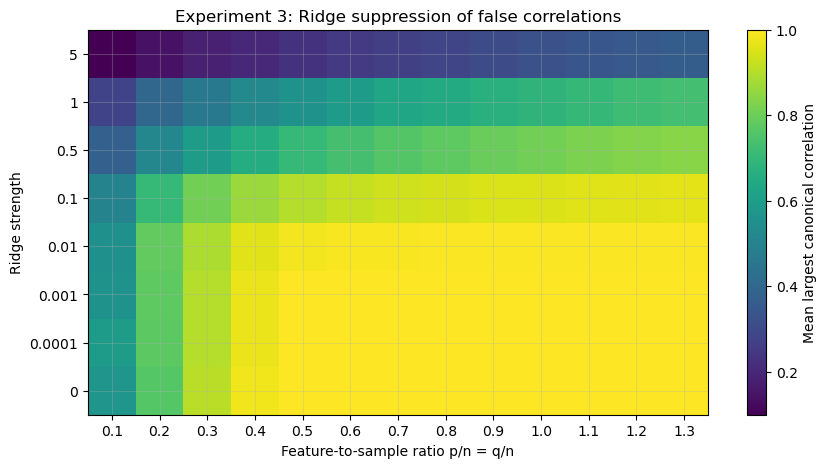

In [17]:
n = 180 if QUICK_MODE else 400
ratios = np.arange(0.10, 1.31, 0.10)
ridge_values = np.array([0.0, 1e-4, 1e-3, 1e-2, 1e-1, 0.5, 1.0, 5.0])
n_rep = 6 if QUICK_MODE else 35

rng = np.random.default_rng(GLOBAL_SEED + 2)
records = []

for ridge in ridge_values:
    for gamma in ratios:
        p = max(1, int(np.floor(n * gamma)))

        for rep in range(n_rep):
            X, Y = generate_null_data(n=n, p=p, q=p, rng=rng)

            fit = fit_cca(
                X,
                Y,
                n_components=1,
                ridge_x=float(ridge),
                ridge_y=float(ridge),
            )

            records.append(
                {
                    "gamma": gamma,
                    "ridge": ridge,
                    "rep": rep,
                    "top_corr": float(fit.correlations[0]),
                }
            )

exp3 = pd.DataFrame(records)

heatmap3 = (
    exp3.groupby(["ridge", "gamma"])["top_corr"]
    .mean()
    .unstack("gamma")
)

display(heatmap3.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heatmap3.to_numpy(), origin="lower", aspect="auto")
ax.set_xticks(np.arange(len(heatmap3.columns)))
ax.set_xticklabels([f"{x:.1f}" for x in heatmap3.columns])
ax.set_yticks(np.arange(len(heatmap3.index)))
ax.set_yticklabels([f"{x:g}" for x in heatmap3.index])
ax.set(
    title="Experiment 3: Ridge suppression of false correlations",
    xlabel="Feature-to-sample ratio p/n = q/n",
    ylabel="Ridge strength",
)
fig.colorbar(im, ax=ax, label="Mean largest canonical correlation")
plt.show()

## Results

- Ridge values that noticeably suppress inflation:
- Regions where ordinary CCA is unstable:
- Remaining false correlation after regularization:
- Questions raised:

# Experiment 4 — Controlled shared-signal experiment

## Purpose

Check whether regularization suppresses noise while preserving a real shared factor.

A method that forces every correlation toward zero is not useful. We want a good bias–variance trade-off.

,ridge,train_pair_corr,test_pair_corr,latent_recovery_x,latent_recovery_y
0,0.000,1.000,-0.007,0.061,0.062
1,0.000,1.000,0.513,0.724,0.704
2,0.001,1.000,0.514,0.725,0.705
3,0.010,1.000,0.527,0.734,0.715
4,0.100,0.996,0.604,0.784,0.768
5,0.500,0.974,0.693,0.838,0.827
6,1.000,0.957,0.723,0.854,0.846
7,5.000,0.908,0.758,0.873,0.868
8,10.000,0.891,0.763,0.876,0.872


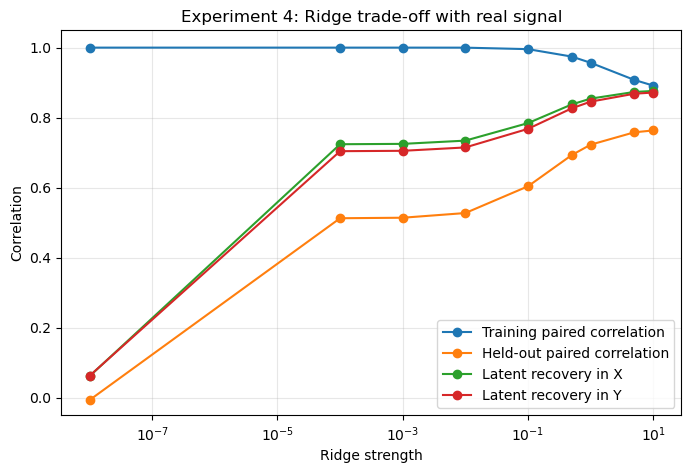

In [18]:
n_train = 220 if QUICK_MODE else 600
n_test = 1200 if QUICK_MODE else 4000
p = 160 if QUICK_MODE else 350
q = 160 if QUICK_MODE else 350
latent_dim = 1
signal_strength = 2.0
noise_std = 1.0
ridge_values = np.array([0.0, 1e-4, 1e-3, 1e-2, 1e-1, 0.5, 1.0, 5.0, 10.0])
n_rep = 8 if QUICK_MODE else 50

rng = np.random.default_rng(GLOBAL_SEED + 3)
records = []

for rep in range(n_rep):
    train = generate_shared_signal_data(
        n=n_train,
        p=p,
        q=q,
        latent_dim=latent_dim,
        signal_strength=signal_strength,
        noise_std=noise_std,
        rng=rng,
    )

    Z_test = rng.standard_normal((n_test, latent_dim))
    X_test = signal_strength * (Z_test @ train.loadings_x.T) + noise_std * rng.standard_normal((n_test, p))
    Y_test = signal_strength * (Z_test @ train.loadings_y.T) + noise_std * rng.standard_normal((n_test, q))

    for ridge in ridge_values:
        fit = fit_cca(
            train.X,
            train.Y,
            n_components=1,
            ridge_x=float(ridge),
            ridge_y=float(ridge),
        )

        Xtr, Ytr = project_cca(fit, train.X, train.Y)
        Xte, Yte = project_cca(fit, X_test, Y_test)

        records.append(
            {
                "rep": rep,
                "ridge": ridge,
                "train_pair_corr": columnwise_correlations(Xtr, Ytr)[0],
                "test_pair_corr": columnwise_correlations(Xte, Yte)[0],
                "latent_recovery_x": abs(np.corrcoef(Xte[:, 0], Z_test[:, 0])[0, 1]),
                "latent_recovery_y": abs(np.corrcoef(Yte[:, 0], Z_test[:, 0])[0, 1]),
            }
        )

exp4 = pd.DataFrame(records)

summary4 = (
    exp4.groupby("ridge")
    .agg(
        train_pair_corr=("train_pair_corr", "mean"),
        test_pair_corr=("test_pair_corr", "mean"),
        latent_recovery_x=("latent_recovery_x", "mean"),
        latent_recovery_y=("latent_recovery_y", "mean"),
    )
    .reset_index()
)

display(summary4.round(3))

fig, ax = plt.subplots()
x = summary4["ridge"] + 1e-8
ax.semilogx(x, summary4["train_pair_corr"], marker="o", label="Training paired correlation")
ax.semilogx(x, summary4["test_pair_corr"], marker="o", label="Held-out paired correlation")
ax.semilogx(x, summary4["latent_recovery_x"], marker="o", label="Latent recovery in X")
ax.semilogx(x, summary4["latent_recovery_y"], marker="o", label="Latent recovery in Y")
ax.set(
    title="Experiment 4: Ridge trade-off with real signal",
    xlabel="Ridge strength",
    ylabel="Correlation",
    ylim=(-0.05, 1.05),
)
ax.legend()
plt.show()

## Results

- Ridge range with best held-out recovery:
- Ridge values that begin to damage the real signal:
- Training-versus-test difference:
- Questions raised:

# Experiment 5 — Train-versus-test inflation under the null model

## Purpose

Show directly that the large training correlation does not generalize.

Fit CCA directions on independent training data, then evaluate the same directions on fresh independent test data.

,gamma,mean_train_corr,mean_test_corr,mean_abs_test_corr
0,0.05,0.388,-0.010,0.021
1,0.10,0.564,-0.003,0.028
2,0.15,0.696,0.006,0.022
3,0.20,0.779,0.002,0.030
4,0.25,0.856,-0.010,0.025


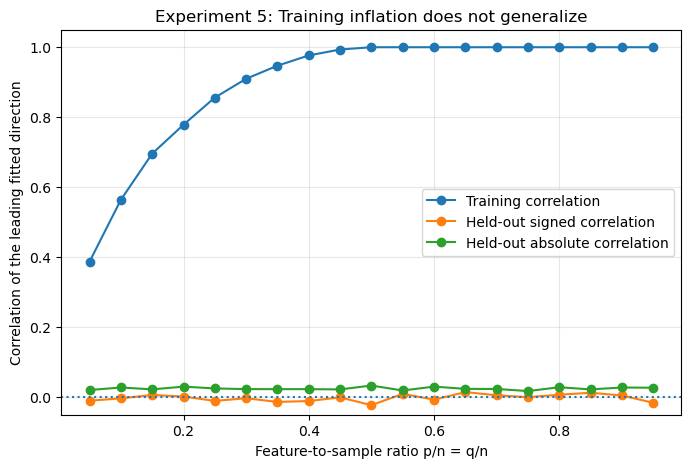

In [19]:
n_train = 180 if QUICK_MODE else 450
n_test = 1000 if QUICK_MODE else 4000
ratios = np.arange(0.05, 0.96, 0.05)
n_rep = 15 if QUICK_MODE else 100

rng = np.random.default_rng(GLOBAL_SEED + 4)
records = []

for gamma in ratios:
    p = max(1, int(np.floor(n_train * gamma)))

    for rep in range(n_rep):
        X_train, Y_train = generate_null_data(n_train, p, p, rng)
        X_test, Y_test = generate_null_data(n_test, p, p, rng)

        fit = fit_cca(X_train, Y_train, n_components=1)

        train_corr, test_corr = leading_train_test_corr(
            fit,
            X_train,
            Y_train,
            X_test,
            Y_test,
        )

        records.append(
            {
                "gamma": gamma,
                "rep": rep,
                "train_corr": train_corr,
                "test_corr": test_corr,
                "abs_test_corr": abs(test_corr),
            }
        )

exp5 = pd.DataFrame(records)

summary5 = (
    exp5.groupby("gamma")
    .agg(
        mean_train_corr=("train_corr", "mean"),
        mean_test_corr=("test_corr", "mean"),
        mean_abs_test_corr=("abs_test_corr", "mean"),
    )
    .reset_index()
)

display(summary5.head().round(3))

fig, ax = plt.subplots()
ax.plot(summary5["gamma"], summary5["mean_train_corr"], marker="o", label="Training correlation")
ax.plot(summary5["gamma"], summary5["mean_test_corr"], marker="o", label="Held-out signed correlation")
ax.plot(summary5["gamma"], summary5["mean_abs_test_corr"], marker="o", label="Held-out absolute correlation")
ax.axhline(0.0, linestyle=":")
ax.set(
    title="Experiment 5: Training inflation does not generalize",
    xlabel="Feature-to-sample ratio p/n = q/n",
    ylabel="Correlation of the leading fitted direction",
    ylim=(-0.05, 1.05),
)
ax.legend()
plt.show()

## Results

- Training correlation:
- Held-out correlation:
- Generalization gap:
- Questions raised:

# Experiment 6 — Compare stabilization strategies

## Purpose

Compare several methods for controlling instability:

1. Ordinary CCA  
2. Ridge CCA  
3. PCA before CCA  
4. Ledoit–Wolf covariance shrinkage  

Each method is evaluated on null data and controlled shared-signal data.

In [20]:
@dataclass
class PCACCAFit:
    cca_fit: CCAFit
    pca_x: np.ndarray
    pca_y: np.ndarray
    mean_x: np.ndarray
    mean_y: np.ndarray


def fit_pca_then_cca(
    X: np.ndarray,
    Y: np.ndarray,
    pca_components: int,
    ridge: float = 0.0,
) -> PCACCAFit:
    mean_x = X.mean(axis=0, keepdims=True)
    mean_y = Y.mean(axis=0, keepdims=True)

    Xc = X - mean_x
    Yc = Y - mean_y

    _, _, Vtx = np.linalg.svd(Xc, full_matrices=False)
    _, _, Vty = np.linalg.svd(Yc, full_matrices=False)

    pca_x = Vtx[: min(pca_components, Vtx.shape[0])].T
    pca_y = Vty[: min(pca_components, Vty.shape[0])].T

    cca_fit = fit_cca(
        Xc @ pca_x,
        Yc @ pca_y,
        n_components=1,
        ridge_x=ridge,
        ridge_y=ridge,
    )

    return PCACCAFit(
        cca_fit=cca_fit,
        pca_x=pca_x,
        pca_y=pca_y,
        mean_x=mean_x,
        mean_y=mean_y,
    )


def project_pca_then_cca(
    fit: PCACCAFit,
    X: np.ndarray,
    Y: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    X_reduced = (X - fit.mean_x) @ fit.pca_x
    Y_reduced = (Y - fit.mean_y) @ fit.pca_y
    return project_cca(fit.cca_fit, X_reduced, Y_reduced)


def fit_ledoit_wolf_cca(
    X: np.ndarray,
    Y: np.ndarray,
    n_components: int = 1,
) -> CCAFit:
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    mean_x = X.mean(axis=0, keepdims=True)
    mean_y = Y.mean(axis=0, keepdims=True)

    Xc = X - mean_x
    Yc = Y - mean_y

    S_xx = LedoitWolf(assume_centered=True).fit(Xc).covariance_
    S_yy = LedoitWolf(assume_centered=True).fit(Yc).covariance_
    S_xy = (Xc.T @ Yc) / max(X.shape[0] - 1, 1)

    W_x = inverse_sqrt_psd(S_xx)
    W_y = inverse_sqrt_psd(S_yy)

    T = W_x @ S_xy @ W_y
    U, singular_values, Vt = np.linalg.svd(T, full_matrices=False)

    k = min(n_components, len(singular_values))

    return CCAFit(
        correlations=singular_values[:k],
        directions_x=W_x @ U[:, :k],
        directions_y=W_y @ Vt.T[:, :k],
        mean_x=mean_x,
        mean_y=mean_y,
    )

In [21]:
n_train = 180 if QUICK_MODE else 450
n_test = 1200 if QUICK_MODE else 4000
p = 150 if QUICK_MODE else 350
q = 150 if QUICK_MODE else 350
n_rep = 8 if QUICK_MODE else 50

ridge = 0.5
pca_components = min(40, n_train // 3)

methods = [
    "Ordinary CCA",
    "Ridge CCA",
    "PCA before CCA",
    "Ledoit-Wolf shrinkage",
]

rng = np.random.default_rng(GLOBAL_SEED + 5)
records = []

for rep in range(n_rep):
    # Null setting
    X_train, Y_train = generate_null_data(n_train, p, q, rng)
    X_test, Y_test = generate_null_data(n_test, p, q, rng)

    fit = fit_cca(X_train, Y_train, n_components=1)
    train_corr, test_corr = leading_train_test_corr(fit, X_train, Y_train, X_test, Y_test)
    records.append({"rep": rep, "setting": "Null", "method": "Ordinary CCA", "train_corr": train_corr, "test_corr": test_corr})

    fit = fit_cca(X_train, Y_train, n_components=1, ridge_x=ridge, ridge_y=ridge)
    train_corr, test_corr = leading_train_test_corr(fit, X_train, Y_train, X_test, Y_test)
    records.append({"rep": rep, "setting": "Null", "method": "Ridge CCA", "train_corr": train_corr, "test_corr": test_corr})

    fit_pca = fit_pca_then_cca(X_train, Y_train, pca_components=pca_components)
    Xtr, Ytr = project_pca_then_cca(fit_pca, X_train, Y_train)
    Xte, Yte = project_pca_then_cca(fit_pca, X_test, Y_test)
    records.append({"rep": rep, "setting": "Null", "method": "PCA before CCA", "train_corr": columnwise_correlations(Xtr, Ytr)[0], "test_corr": columnwise_correlations(Xte, Yte)[0]})

    fit = fit_ledoit_wolf_cca(X_train, Y_train)
    train_corr, test_corr = leading_train_test_corr(fit, X_train, Y_train, X_test, Y_test)
    records.append({"rep": rep, "setting": "Null", "method": "Ledoit-Wolf shrinkage", "train_corr": train_corr, "test_corr": test_corr})

    # Shared-signal setting
    train_signal = generate_shared_signal_data(
        n=n_train,
        p=p,
        q=q,
        latent_dim=1,
        signal_strength=2.0,
        noise_std=1.0,
        rng=rng,
    )

    Z_test = rng.standard_normal((n_test, 1))
    X_test = 2.0 * (Z_test @ train_signal.loadings_x.T) + rng.standard_normal((n_test, p))
    Y_test = 2.0 * (Z_test @ train_signal.loadings_y.T) + rng.standard_normal((n_test, q))

    fit = fit_cca(train_signal.X, train_signal.Y, n_components=1)
    train_corr, test_corr = leading_train_test_corr(fit, train_signal.X, train_signal.Y, X_test, Y_test)
    records.append({"rep": rep, "setting": "Signal", "method": "Ordinary CCA", "train_corr": train_corr, "test_corr": test_corr})

    fit = fit_cca(train_signal.X, train_signal.Y, n_components=1, ridge_x=ridge, ridge_y=ridge)
    train_corr, test_corr = leading_train_test_corr(fit, train_signal.X, train_signal.Y, X_test, Y_test)
    records.append({"rep": rep, "setting": "Signal", "method": "Ridge CCA", "train_corr": train_corr, "test_corr": test_corr})

    fit_pca = fit_pca_then_cca(train_signal.X, train_signal.Y, pca_components=pca_components)
    Xtr, Ytr = project_pca_then_cca(fit_pca, train_signal.X, train_signal.Y)
    Xte, Yte = project_pca_then_cca(fit_pca, X_test, Y_test)
    records.append({"rep": rep, "setting": "Signal", "method": "PCA before CCA", "train_corr": columnwise_correlations(Xtr, Ytr)[0], "test_corr": columnwise_correlations(Xte, Yte)[0]})

    fit = fit_ledoit_wolf_cca(train_signal.X, train_signal.Y)
    train_corr, test_corr = leading_train_test_corr(fit, train_signal.X, train_signal.Y, X_test, Y_test)
    records.append({"rep": rep, "setting": "Signal", "method": "Ledoit-Wolf shrinkage", "train_corr": train_corr, "test_corr": test_corr})

exp6 = pd.DataFrame(records)
exp6["abs_test_corr"] = exp6["test_corr"].abs()

summary6 = (
    exp6.groupby(["setting", "method"])
    .agg(
        mean_train_corr=("train_corr", "mean"),
        mean_test_corr=("test_corr", "mean"),
        mean_abs_test_corr=("abs_test_corr", "mean"),
    )
    .reset_index()
)

display(summary6.round(3))

,setting,method,mean_train_corr,mean_test_corr,mean_abs_test_corr
0,Null,Ledoit-Wolf shrinkage,0.848,0.014,0.027
1,Null,Ordinary CCA,1.000,0.003,0.026
2,Null,PCA before CCA,0.822,0.003,0.022
3,Null,Ridge CCA,0.981,0.009,0.024
4,Signal,Ledoit-Wolf shrinkage,0.910,0.755,0.755
5,Signal,Ordinary CCA,1.000,-0.012,0.027
6,Signal,PCA before CCA,0.895,0.680,0.680
7,Signal,Ridge CCA,0.979,0.689,0.689


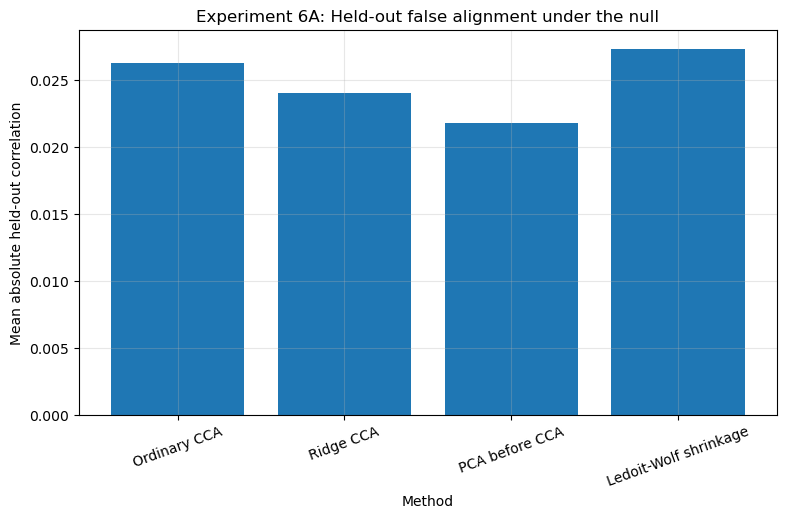

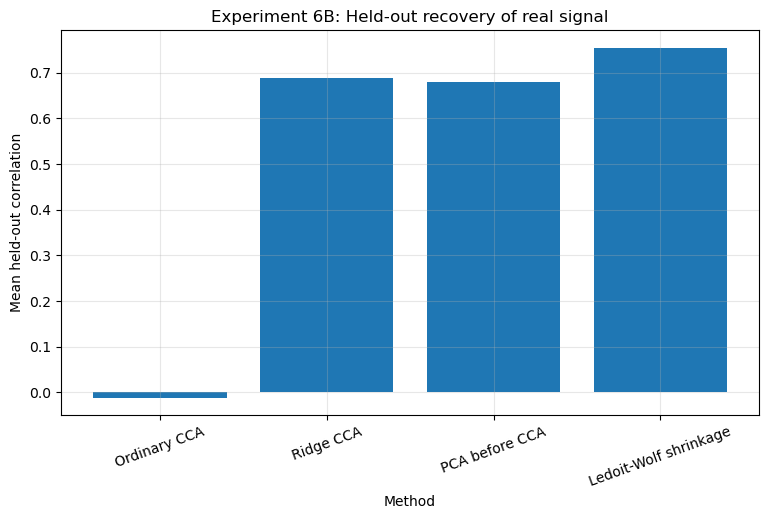

In [22]:
null_summary = (
    exp6[exp6["setting"] == "Null"]
    .groupby("method")["abs_test_corr"]
    .mean()
    .reindex(methods)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(null_summary.index, null_summary.values)
ax.set(
    title="Experiment 6A: Held-out false alignment under the null",
    xlabel="Method",
    ylabel="Mean absolute held-out correlation",
)
ax.tick_params(axis="x", rotation=20)
plt.show()

signal_summary = (
    exp6[exp6["setting"] == "Signal"]
    .groupby("method")["test_corr"]
    .mean()
    .reindex(methods)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(signal_summary.index, signal_summary.values)
ax.set(
    title="Experiment 6B: Held-out recovery of real signal",
    xlabel="Method",
    ylabel="Mean held-out correlation",
)
ax.tick_params(axis="x", rotation=20)
plt.show()

## Results

| Method | Null held-out correlation | Signal held-out correlation | Notes |
|---|---:|---:|---|
| Ordinary CCA |  |  |  |
| Ridge CCA |  |  |  |
| PCA before CCA |  |  |  |
| Ledoit–Wolf shrinkage |  |  |  |

- Best trade-off:
- Questions raised:

# Experiment 7 — Regularizing the objective of a learned linear contrastive encoder

## Purpose

Test whether a related regularization principle helps learned linear encoders avoid fitting accidental alignments.

This experiment is intentionally exploratory:

- CCA is solved with covariance matrices and SVD.
- Linear contrastive encoders are trained with an objective function.

A CCA remedy does not automatically transfer, but it may suggest a useful intervention.

In [12]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

    TORCH_AVAILABLE = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("PyTorch available. Device:", DEVICE)
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch is not installed. Experiment 7 will be skipped.")

PyTorch available. Device: cpu


In [13]:
if TORCH_AVAILABLE:
    class LinearTwoViewEncoder(nn.Module):
        def __init__(self, p: int, q: int, embedding_dim: int):
            super().__init__()
            self.encoder_x = nn.Linear(p, embedding_dim, bias=False)
            self.encoder_y = nn.Linear(q, embedding_dim, bias=False)

            nn.init.orthogonal_(self.encoder_x.weight)
            nn.init.orthogonal_(self.encoder_y.weight)

        def forward(self, X, Y):
            return self.encoder_x(X), self.encoder_y(Y)


    def symmetric_contrastive_loss(z_x, z_y, temperature, l2_strength, model):
        z_x = F.normalize(z_x, dim=1)
        z_y = F.normalize(z_y, dim=1)

        logits = (z_x @ z_y.T) / temperature
        labels = torch.arange(logits.shape[0], device=logits.device)

        loss_xy = F.cross_entropy(logits, labels)
        loss_yx = F.cross_entropy(logits.T, labels)

        l2_penalty = (
            model.encoder_x.weight.pow(2).sum()
            + model.encoder_y.weight.pow(2).sum()
        )

        return 0.5 * (loss_xy + loss_yx) + l2_strength * l2_penalty


    def alignment_gap(z_x: np.ndarray, z_y: np.ndarray) -> float:
        z_x = z_x / np.maximum(np.linalg.norm(z_x, axis=1, keepdims=True), 1e-12)
        z_y = z_y / np.maximum(np.linalg.norm(z_y, axis=1, keepdims=True), 1e-12)

        similarities = z_x @ z_y.T
        matched = np.diag(similarities).mean()
        mismatched = (
            similarities.sum() - np.trace(similarities)
        ) / (similarities.size - similarities.shape[0])

        return float(matched - mismatched)


    def train_linear_encoder(
        X_train,
        Y_train,
        X_test,
        Y_test,
        embedding_dim,
        l2_strength,
        temperature=0.2,
        learning_rate=5e-3,
        epochs=200,
        seed=123,
    ):
        torch.manual_seed(seed)

        model = LinearTwoViewEncoder(
            p=X_train.shape[1],
            q=Y_train.shape[1],
            embedding_dim=embedding_dim,
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        Xtr = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
        Ytr = torch.tensor(Y_train, dtype=torch.float32, device=DEVICE)
        Xte = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
        Yte = torch.tensor(Y_test, dtype=torch.float32, device=DEVICE)

        for _ in range(epochs):
            optimizer.zero_grad(set_to_none=True)

            z_x, z_y = model(Xtr, Ytr)
            loss = symmetric_contrastive_loss(
                z_x=z_x,
                z_y=z_y,
                temperature=temperature,
                l2_strength=l2_strength,
                model=model,
            )

            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():
            z_x_train, z_y_train = model(Xtr, Ytr)
            z_x_test, z_y_test = model(Xte, Yte)

        z_x_train = z_x_train.cpu().numpy()
        z_y_train = z_y_train.cpu().numpy()
        z_x_test = z_x_test.cpu().numpy()
        z_y_test = z_y_test.cpu().numpy()

        return {
            "train_alignment_gap": alignment_gap(z_x_train, z_y_train),
            "test_alignment_gap": alignment_gap(z_x_test, z_y_test),
            "train_embedding_corr": float(fit_cca(z_x_train, z_y_train, n_components=1, ridge_x=1e-8).correlations[0]),
            "test_embedding_corr": float(fit_cca(z_x_test, z_y_test, n_components=1, ridge_x=1e-8).correlations[0]),
        }

In [14]:
if TORCH_AVAILABLE:
    n_train = 160 if QUICK_MODE else 350
    n_test = 800 if QUICK_MODE else 2500
    gamma_values = [0.20, 0.50, 0.80] if QUICK_MODE else [0.10, 0.25, 0.40, 0.55, 0.70, 0.85]
    l2_values = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]
    embedding_dim = 8
    n_rep = 2 if QUICK_MODE else 8
    epochs = 160 if QUICK_MODE else 400

    rng = np.random.default_rng(GLOBAL_SEED + 6)
    records = []

    start = time.time()

    for gamma in gamma_values:
        p = max(2, int(np.floor(n_train * gamma)))

        for l2_strength in l2_values:
            for rep in range(n_rep):
                X_train, Y_train = generate_null_data(n_train, p, p, rng)
                X_test, Y_test = generate_null_data(n_test, p, p, rng)

                metrics = train_linear_encoder(
                    X_train=X_train,
                    Y_train=Y_train,
                    X_test=X_test,
                    Y_test=Y_test,
                    embedding_dim=embedding_dim,
                    l2_strength=float(l2_strength),
                    epochs=epochs,
                    seed=GLOBAL_SEED + rep,
                )

                records.append(
                    {
                        "gamma": gamma,
                        "p": p,
                        "l2_strength": l2_strength,
                        "rep": rep,
                        **metrics,
                    }
                )

    print(f"Experiment 7 runtime: {time.time() - start:.1f} seconds")

    exp7 = pd.DataFrame(records)

    summary7 = (
        exp7.groupby(["gamma", "l2_strength"])
        .agg(
            train_alignment_gap=("train_alignment_gap", "mean"),
            test_alignment_gap=("test_alignment_gap", "mean"),
            train_embedding_corr=("train_embedding_corr", "mean"),
            test_embedding_corr=("test_embedding_corr", "mean"),
        )
        .reset_index()
    )

    display(summary7.round(4))
else:
    print("Skipped because PyTorch is unavailable.")

Experiment 7 runtime: 3.2 seconds


,gamma,l2_strength,train_alignment_gap,test_alignment_gap,train_embedding_corr,test_embedding_corr
0,0.2,0.0000,0.7200,-0.0031,0.7222,0.1724
1,0.2,0.0001,0.7278,-0.0078,0.7768,0.1467
2,0.2,0.0010,0.7330,0.0078,0.7375,0.1720
3,0.2,0.0100,0.7109,-0.0035,0.7171,0.1843
4,0.2,0.1000,0.7459,-0.0019,0.7121,0.1772
5,0.5,0.0000,0.9854,0.0059,0.8959,0.1608
6,0.5,0.0001,0.9862,0.0009,0.8973,0.1530
7,0.5,0.0010,0.9857,0.0063,0.8797,0.1489
8,0.5,0.0100,0.9948,0.0051,0.8832,0.1741
9,0.5,0.1000,0.9980,0.0017,0.8978,0.1676


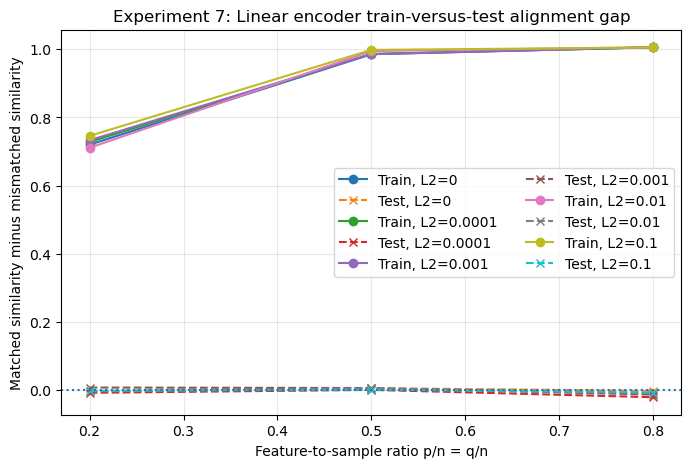

In [15]:
if TORCH_AVAILABLE:
    fig, ax = plt.subplots()

    for l2_strength in l2_values:
        subset = summary7[summary7["l2_strength"] == l2_strength].sort_values("gamma")

        ax.plot(
            subset["gamma"],
            subset["train_alignment_gap"],
            marker="o",
            label=f"Train, L2={l2_strength:g}",
        )

        ax.plot(
            subset["gamma"],
            subset["test_alignment_gap"],
            marker="x",
            linestyle="--",
            label=f"Test, L2={l2_strength:g}",
        )

    ax.axhline(0.0, linestyle=":")
    ax.set(
        title="Experiment 7: Linear encoder train-versus-test alignment gap",
        xlabel="Feature-to-sample ratio p/n = q/n",
        ylabel="Matched similarity minus mismatched similarity",
    )
    ax.legend(ncol=2)
    plt.show()

## Results

- L2 values that reduce the train-versus-test gap:
- Training alignment:
- Held-out alignment:
- Does regularization help without merely collapsing the encoder?
- Questions raised:

### Recommended extension

Repeat Experiment 7 using the controlled shared-signal generator from Experiment 4. The goal is to test whether regularization reduces null-model overfitting while preserving genuine paired structure.

# Final synthesis

## Main findings

- 

## Most promising remedy

- 

## Questions for the next notebook

- How should regularization strength depend on \(p/n\) and \(q/n\)?
- Does the best CCA stabilization method improve linear contrastive encoders?
- Which ideas still help after replacing linear encoders with nonlinear neural networks?
- Can shuffled-pair baselines be used as a practical diagnostic for spurious alignment?